📊 Carregant dades des de ../data/processed/historial_experiments.csv...
🗺️ Generant Gràfic 3D...


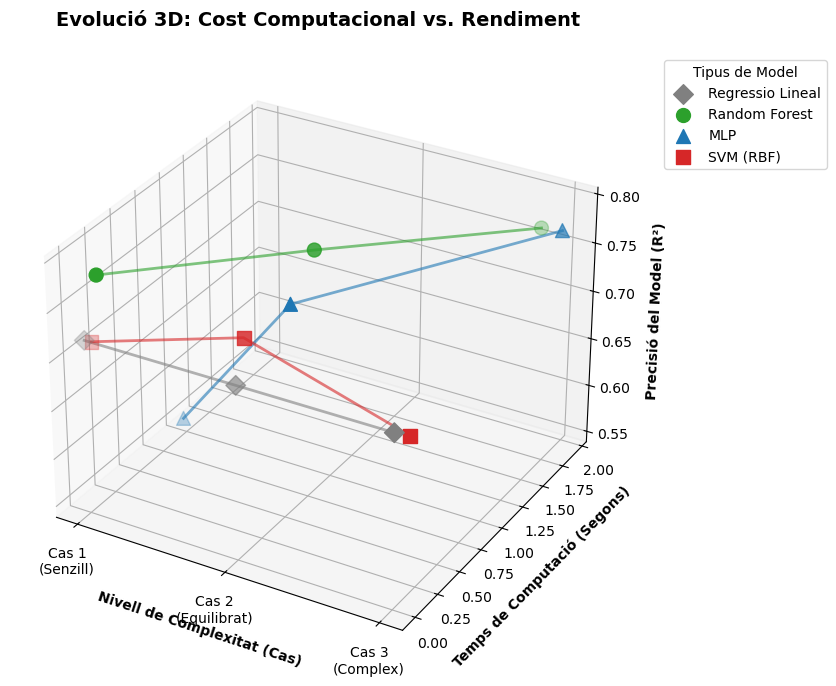

📈 Generant Gràfic 2D d'Eficiència...


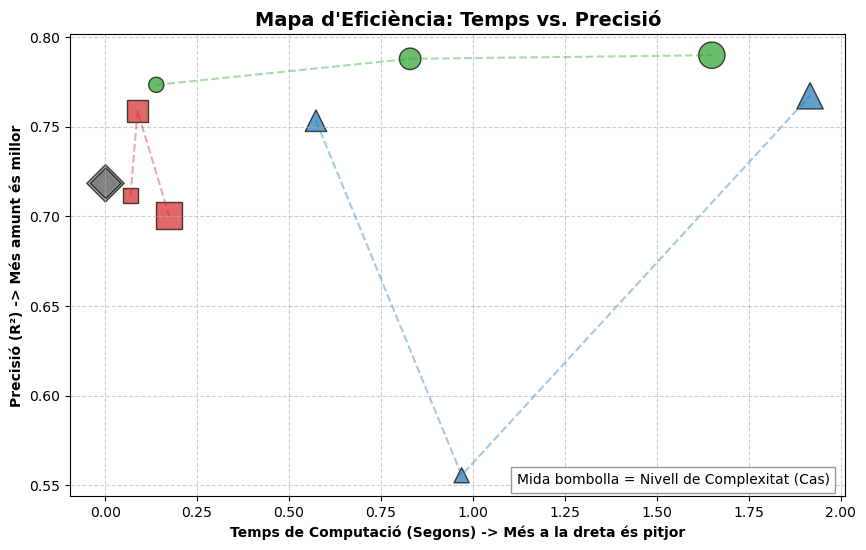

✅ Gràfics guardats amb alta qualitat a /data/processed/


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. CÀRREGA DE DADES (Amb suport per a comes europees)
# ==============================================================================
ruta_logbook = '../data/processed/historial_experiments.csv'
print(f"📊 Carregant dades des de {ruta_logbook}...")

# Llegim assegurant-nos que entén la coma com a decimal
df = pd.read_csv(ruta_logbook, sep=';', decimal=',')
df['Model'] = df['Model'].str.strip() # Neteja d'espais per si de cas

# Colors corporatius per a cada model
colors = {
    'Regressio Lineal': 'gray', 
    'Random Forest': '#2ca02c', # Verd
    'MLP': '#1f77b4',           # Blau
    'SVM (RBF)': '#d62728'      # Vermell
}

marcadors = {'Regressio Lineal': 'D', 'Random Forest': 'o', 'MLP': '^', 'SVM (RBF)': 's'}

# ==============================================================================
# 2. GRÀFIC 3D: Complexitat vs Temps vs R2 (El que va demanar la tutora)
# ==============================================================================
print("🗺️ Generant Gràfic 3D...")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for model in df['Model'].unique():
    df_model = df[df['Model'] == model].sort_values(by='Cas_Num')
    
    # Dibuixem els punts
    ax.scatter(df_model['Cas_Num'], df_model['Temps_Segons'], df_model['R2_Test'],
               c=colors[model], marker=marcadors[model], s=100, label=model, depthshade=True)
    
    # Dibuixem la línia de la trajectòria (evolució)
    ax.plot(df_model['Cas_Num'], df_model['Temps_Segons'], df_model['R2_Test'], 
            color=colors[model], alpha=0.6, linewidth=2)

ax.set_xlabel('\nNivell de Complexitat (Cas)', fontweight='bold')
ax.set_ylabel('\nTemps de Computació (Segons)', fontweight='bold')
ax.set_zlabel('\nPrecisió del Model (R²)', fontweight='bold')
ax.set_title('Evolució 3D: Cost Computacional vs. Rendiment', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Cas 1\n(Senzill)', 'Cas 2\n(Equilibrat)', 'Cas 3\n(Complex)'])
plt.legend(title='Tipus de Model', loc='upper left', bbox_to_anchor=(1.05, 1))

# Guardem la imatge
plt.savefig('../data/processed/Grafic_3D_Rendiment.png', bbox_inches='tight', dpi=300)
plt.show()

# ==============================================================================
# 3. GRÀFIC 2D DE BOMBOLLES (Solució Nativa Matplotlib)
# ==============================================================================
print("📈 Generant Gràfic 2D d'Eficiència...")
plt.figure(figsize=(10, 6))

for model in df['Model'].unique():
    df_model = df[df['Model'] == model].sort_values(by='Temps_Segons')
    
    # Utilitzem plt.scatter en comptes de sns.scatterplot per evitar l'error de seaborn
    # Calculem la mida: Cas 1 -> petit, Cas 2 -> mitjà, Cas 3 -> gran
    mides = df_model['Cas_Num'] * 120 
    
    plt.scatter(df_model['Temps_Segons'], df_model['R2_Test'], 
                s=mides, c=colors[model], marker=marcadors[model], 
                label=model, alpha=0.7, edgecolors='black')
    
    # Línia de tendència (evolució del temps)
    plt.plot(df_model['Temps_Segons'], df_model['R2_Test'], 
             color=colors[model], linestyle='--', alpha=0.4)

plt.title('Mapa d\'Eficiència: Temps vs. Precisió', fontsize=14, fontweight='bold')
plt.xlabel('Temps de Computació (Segons) -> Més a la dreta és pitjor', fontweight='bold')
plt.ylabel('Precisió (R²) -> Més amunt és millor', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Creem la llegenda general
llegenda_models = plt.legend(title='Tipus de Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().add_artist(llegenda_models)

# Afegim una petita nota per explicar les bombolles a la cantonada inferior dreta
plt.text(0.98, 0.02, 'Mida bombolla = Nivell de Complexitat (Cas)', 
         horizontalalignment='right', verticalalignment='bottom', 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Guardem la imatge
plt.savefig('../data/processed/Grafic_2D_Eficiencia.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Gràfics guardats amb alta qualitat a /data/processed/")

📊 Carregant dades des de ../data/processed/historial_experiments.csv...
🗺️ Generant Gràfic 3D...


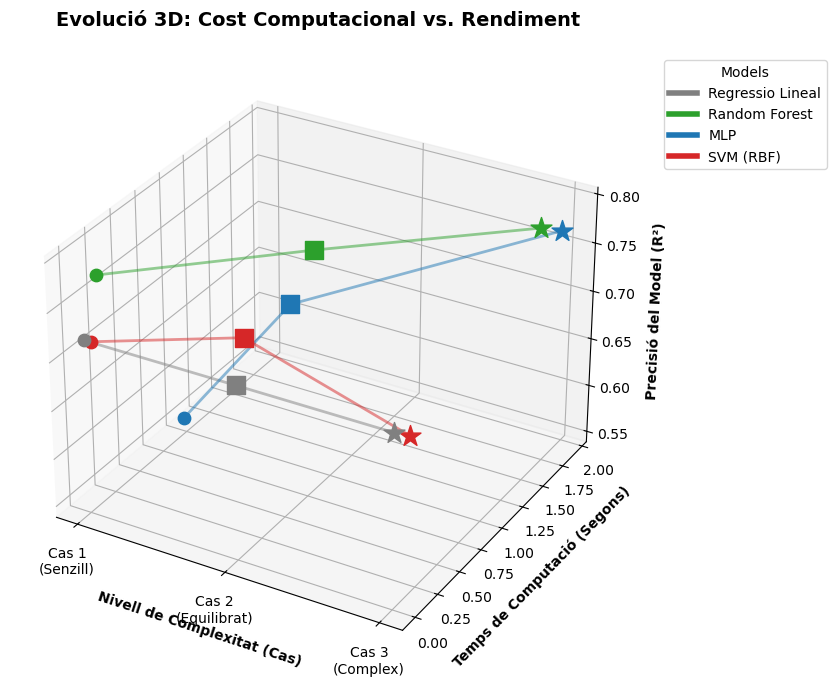

📈 Generant Gràfic 2D d'Eficiència...


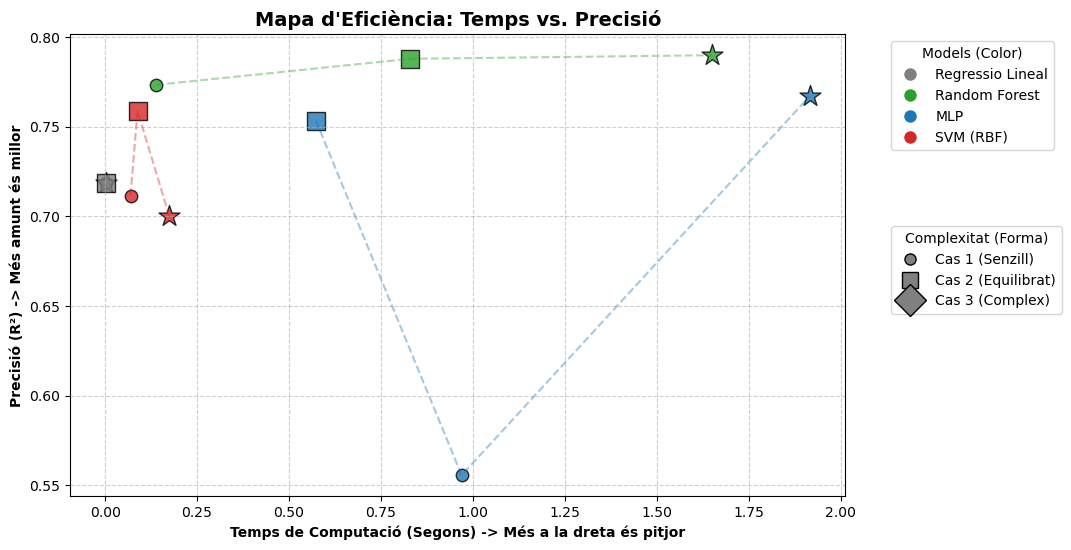

✅ Gràfics guardats amb alta qualitat a /data/processed/


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. CÀRREGA DE DADES 
# ==============================================================================
ruta_logbook = '../data/processed/historial_experiments.csv'
print(f"📊 Carregant dades des de {ruta_logbook}...")

df = pd.read_csv(ruta_logbook, sep=';', decimal=',')
df['Model'] = df['Model'].str.strip()

# DICCIONARI 1: COLOR = MODEL
colors = {
    'Regressio Lineal': 'gray', 
    'Random Forest': '#2ca02c', # Verd
    'MLP': '#1f77b4',           # Blau
    'SVM (RBF)': '#d62728'      # Vermell
}

# DICCIONARI 2: FORMA I MIDA = CAS DE COMPLEXITAT
# Cas 1: Rodona petita, Cas 2: Quadrat mitjà, Cas 3: Diamant gran
formes_cas = {
    1: 'o', # Cercle
    2: 's', # Square (Quadrat)
    3: '*'  # Estrella
}
mides_cas = {1: 80, 2: 150, 3: 250}

# ==============================================================================
# 2. GRÀFIC 3D: Evolució Cost vs Rendiment
# ==============================================================================
print("🗺️ Generant Gràfic 3D...")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for model in df['Model'].unique():
    df_model = df[df['Model'] == model].sort_values(by='Cas_Num')
    
    # Dibuixem els punts llegint la forma segons el 'Cas_Num'
    for idx, row in df_model.iterrows():
        cas = int(row['Cas_Num'])
        ax.scatter(row['Cas_Num'], row['Temps_Segons'], row['R2_Test'],
                   c=colors[model], marker=formes_cas[cas], s=mides_cas[cas], depthshade=True)
    
    # Dibuixem la línia de trajectòria
    ax.plot(df_model['Cas_Num'], df_model['Temps_Segons'], df_model['R2_Test'], 
            color=colors[model], alpha=0.5, linewidth=2)

ax.set_xlabel('\nNivell de Complexitat (Cas)', fontweight='bold')
ax.set_ylabel('\nTemps de Computació (Segons)', fontweight='bold')
ax.set_zlabel('\nPrecisió del Model (R²)', fontweight='bold')
ax.set_title('Evolució 3D: Cost Computacional vs. Rendiment', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Cas 1\n(Senzill)', 'Cas 2\n(Equilibrat)', 'Cas 3\n(Complex)'])

# Llegenda manual pel 3D
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=color, lw=4, label=model) for model, color in colors.items()]
ax.legend(handles=legend_elements, title='Models', loc='upper left', bbox_to_anchor=(1.05, 1))

plt.savefig('../data/processed/Grafic_3D_Rendiment.png', bbox_inches='tight', dpi=300)
plt.show()

# ==============================================================================
# 3. GRÀFIC 2D: Mapa d'Eficiència
# ==============================================================================
print("📈 Generant Gràfic 2D d'Eficiència...")
plt.figure(figsize=(10, 6))

for model in df['Model'].unique():
    df_model = df[df['Model'] == model].sort_values(by='Temps_Segons')
    
    # Línia de tendència
    plt.plot(df_model['Temps_Segons'], df_model['R2_Test'], color=colors[model], linestyle='--', alpha=0.4)
    
    # Dibuixem els punts llegint la forma segons el 'Cas_Num'
    for idx, row in df_model.iterrows():
        cas = int(row['Cas_Num'])
        plt.scatter(row['Temps_Segons'], row['R2_Test'], 
                    s=mides_cas[cas], c=colors[model], marker=formes_cas[cas], 
                    alpha=0.8, edgecolors='black', linewidth=1)

plt.title('Mapa d\'Eficiència: Temps vs. Precisió', fontsize=14, fontweight='bold')
plt.xlabel('Temps de Computació (Segons) -> Més a la dreta és pitjor', fontweight='bold')
plt.ylabel('Precisió (R²) -> Més amunt és millor', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Creem l'explicació de la llegenda dual (Colors per models, Formes per Casos)
legend_models = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=m) for m, c in colors.items()]
legend_casos = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=8, label='Cas 1 (Senzill)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=12, label='Cas 2 (Equilibrat)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=16, label='Cas 3 (Complex)')
]

leg1 = plt.legend(handles=legend_models, title='Models (Color)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().add_artist(leg1)
plt.legend(handles=legend_casos, title='Complexitat (Forma)', bbox_to_anchor=(1.05, 0.6), loc='upper left')

plt.savefig('../data/processed/Grafic_2D_Eficiencia.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Gràfics guardats amb alta qualitat a /data/processed/")

📊 INICIANT VALIDACIÓ ESTADÍSTICA DEL MODEL...

🗺️ Generant Mapa de Correlacions (Colinealitat)...


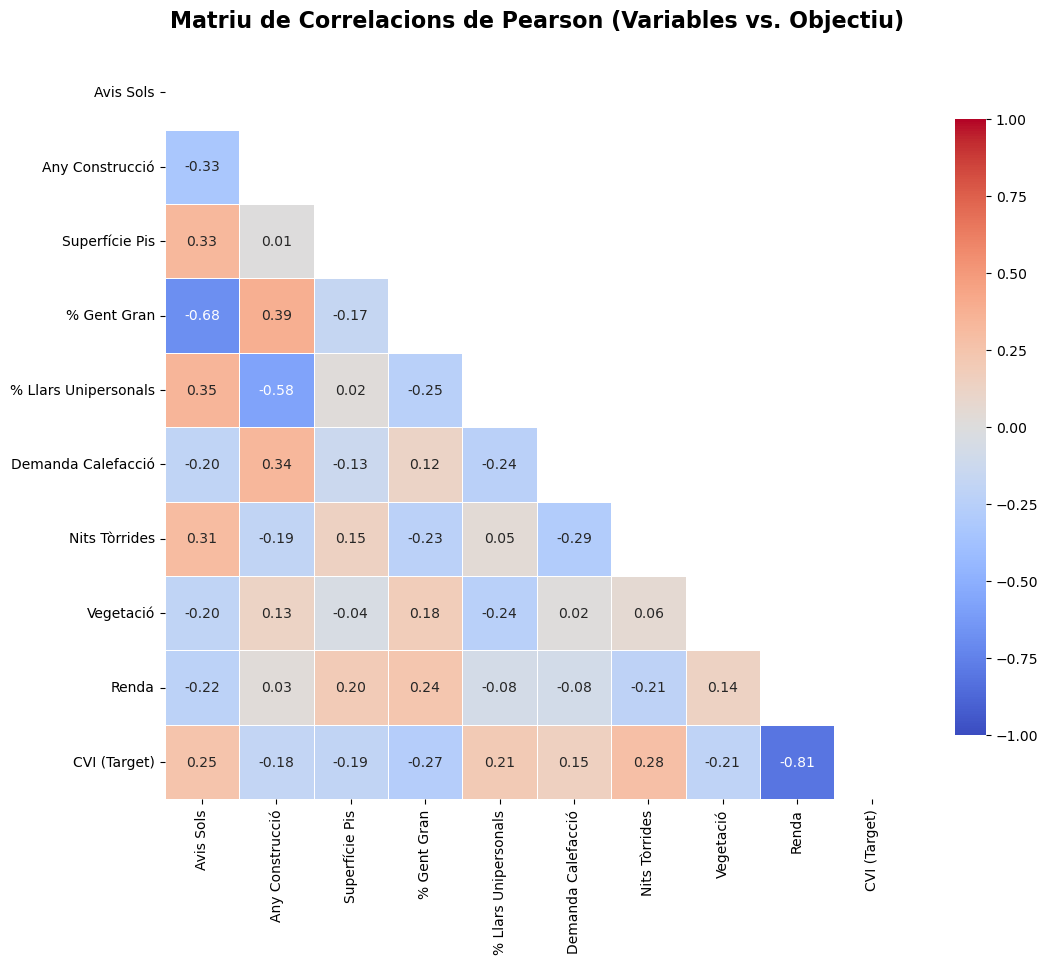


📈 Analitzant la distribució dels errors (Residus)...


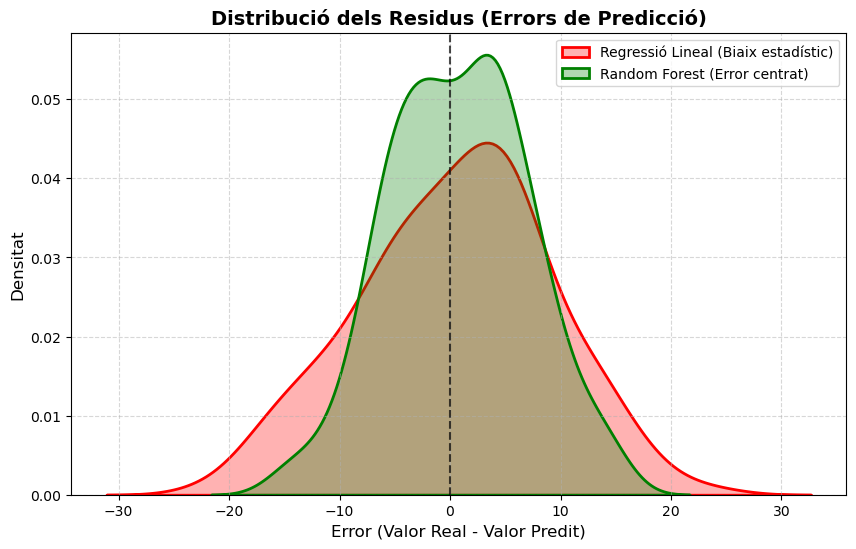


✅ VALIDACIÓ FINALITZADA. Gràfics guardats a /data/processed/


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

print("📊 INICIANT VALIDACIÓ ESTADÍSTICA DEL MODEL...")

# ==============================================================================
# 1. CÀRREGA DE DADES I VARIABLES
# ==============================================================================
ruta_dataset = '../data/processed/04_Master_Dataset_Final_Integrat.xlsx'
df = pd.read_excel(ruta_dataset)

# Utilitzem l'Escenari 4 (El teu escenari de Proxies per veure totes les relacions)
columnes_X = [
    'pad_dom_Llars_1_Avi_Sol', 
    'edificacions_any_Any_Mitja_Ponderat', 
    'edificacions_superficie_Superficie_m2', 
    'percentage_population_over_65__2022-01-01', 
    'percentage_single_person_households__2022-01-01', 
    'heating_thermal_demand_intensity__2025-03-06',
    'torrid_nights__2024-01-01',
    'vegetation_index_avg__2022-01-01'
]
columna_Y = 'CVI__2023-01-01'
columna_Renda = 'renda_disponible_Import_Euros' # La incloem només per veure com es relaciona amb la resta

# ==============================================================================
# 2. MAPA DE CALOR DE CORRELACIONS (PEARSON HEATMAP)
# ==============================================================================
print("\n🗺️ Generant Mapa de Correlacions (Colinealitat)...")

# Agafem només les columnes que ens interessen i netegem els noms per al gràfic
df_corr = df[columnes_X + [columna_Renda, columna_Y]].dropna()
noms_nets = {
    'pad_dom_Llars_1_Avi_Sol': 'Avis Sols',
    'edificacions_any_Any_Mitja_Ponderat': 'Any Construcció',
    'edificacions_superficie_Superficie_m2': 'Superfície Pis',
    'percentage_population_over_65__2022-01-01': '% Gent Gran',
    'percentage_single_person_households__2022-01-01': '% Llars Unipersonals',
    'heating_thermal_demand_intensity__2025-03-06': 'Demanda Calefacció',
    'torrid_nights__2024-01-01': 'Nits Tòrrides',
    'vegetation_index_avg__2022-01-01': 'Vegetació',
    'renda_disponible_Import_Euros': 'Renda',
    'CVI__2023-01-01': 'CVI (Target)'
}
df_corr.rename(columns=noms_nets, inplace=True)

# Calculem la matriu de Pearson
matriu_corr = df_corr.corr()

# Dibuixem el Heatmap
plt.figure(figsize=(12, 10))
mascara = np.triu(np.ones_like(matriu_corr, dtype=bool)) # Amaguem la meitat de dalt perquè és simètrica
sns.heatmap(matriu_corr, mask=mascara, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriu de Correlacions de Pearson (Variables vs. Objectiu)', fontsize=16, fontweight='bold', pad=20)
plt.savefig('../data/processed/Grafic_Correlacions_Heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# ==============================================================================
# 3. ANÀLISI DE RESIDUS (JUSTIFICACIÓ DEL MACHINE LEARNING NO LINEAL)
# ==============================================================================
print("\n📈 Analitzant la distribució dels errors (Residus)...")

X = df_corr.drop(columns=['CVI (Target)', 'Renda']) # Entrenem amb les de l'Escenari 4
y = df_corr['CVI (Target)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Lineal Clàssic
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)
residus_lr = y_test - preds_lr

# Model Avançat (Random Forest)
rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)
residus_rf = y_test - preds_rf

# Dibuixem l'histograma dels residus
plt.figure(figsize=(10, 6))
sns.kdeplot(residus_lr, label='Regressió Lineal (Biaix estadístic)', color='red', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(residus_rf, label='Random Forest (Error centrat)', color='green', fill=True, alpha=0.3, linewidth=2)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribució dels Residus (Errors de Predicció)', fontsize=14, fontweight='bold')
plt.xlabel('Error (Valor Real - Valor Predit)', fontsize=12)
plt.ylabel('Densitat', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('../data/processed/Grafic_Distribucio_Residus.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✅ VALIDACIÓ FINALITZADA. Gràfics guardats a /data/processed/")